In [34]:
from PIL import Image
from IPython.display import display
from array import array
#resources:
#https://giflib.sourceforge.net/whatsinagif/index.html
#https://github.com/qalle2/pygif
#https://bitbanksoftware.blogspot.com/2020/07/a-low-memory-gif-decoder.html



In [77]:

def ByteArrayReverse(Barr):
    l = list(Barr)
    l = l[::-1]
    return bytearray(l)
    
def get_CodeValue(Code,codeTable,byteTable,ColorTableLen):
    if Code < ColorTableLen:
        return Code.to_bytes(1)
    else:
        newCode = Code
        outList = []
        while newCode > ColorTableLen:
            index = newCode-(ColorTableLen+2)
            newCode = codeTable[index]
            outList.append(byteTable[newCode])
        outList.append(newCode)
        outList = outList[::-1]
        return bytearray(outList)

def lzw_Decompress(src,LZW_Min_Code):
    ColorTableLen = 2**LZW_Min_Code
    #print('ColorTableLen:',ColorTableLen)
    #print('LZW_Min_Code:',LZW_Min_Code)
    ClearCode = ColorTableLen
    ImgEndCode = ColorTableLen + 1
    CodeLen = LZW_Min_Code+1
    lastCode = 0
    K = 0
    Code = None
    Codekey = None
    indexStream = bytearray()
    datablock = bytearray(256)
    datablockIndex = 0
    codeTable = array('h')
    byteTable = bytearray()
    byte = 0
    BitIndex = 0
    newTableIndex = ImgEndCode + 1
    ByteCount = 0
    BlockN = 0
    FirstCodeFlag = False
    ZeroBlockLenFlag = False
    while True:       
        Code = bytearray(CodeLen//8+1)
        #print('bc:',ByteCount,' ',end='')
        #print('['+str(newTableIndex)+']',end="")
        #print('('+str(CodeLen)+')',end="")
        #print('|'+str(BitIndex)+'|',end="")
        for i in range(CodeLen):   
            if ByteCount == 0:
                ByteCount = src.read(1)[0]
                datablock = src.read(ByteCount)
                datablockIndex = 0
                #print("BlockN: ",BlockN,"BlockLen: ",ByteCount)
                if ByteCount == 0:
                    ZeroBlockLenFlag = True
                    break
                BlockN += 1
                            
            if BitIndex == 0:
                byte = datablock[datablockIndex]
                datablockIndex += 1
                ByteCount -= 1

            bit = (byte >> BitIndex) & 1
            if bit:
                Code[i//8] = Code[i//8] | 1<<i%8
            BitIndex += 1
            if BitIndex == 8:
                BitIndex = 0
        if ZeroBlockLenFlag:
            break
        #print(' ',end="")
        #binary_string = ''.join(f'{b:08b}' for b in bytearray([Code[-1]]))
        #print(binary_string,' ',end="")
        #binary_string = ''.join(f'{b:08b}' for b in bytearray([Code[0]]))
        #print(binary_string,' ',end="")
        
        CodeKey = int.from_bytes(Code,'little')
        #print(' ',end="")
        #print(CodeKey,end="")
        #print(' -> ',end="")
        #print('')
        if CodeKey == ClearCode:
            #print('Clear Code - Initializing codeTable')
            codeTable = array('h')
            byteTable = bytearray()
            newTableIndex = ImgEndCode+1
            FirstCodeFlag = False
            CodeLen = LZW_Min_Code+1         
        elif CodeKey == ImgEndCode:
            #print('Image End Code - Decoding Complete')
            break
        else:
            if not FirstCodeFlag:
                #print('First Code - Appending to indexStream')
                indexStream += bytearray(get_CodeValue(CodeKey,codeTable,byteTable,ColorTableLen))
                FirstCodeFlag = True
            else:
                if (CodeKey < newTableIndex):
                    codearr = get_CodeValue(CodeKey,codeTable,byteTable,ColorTableLen)
                    indexStream += codearr
                    K = codearr[0]
                    #print('Found adding to stream -',CodeKey,codearr)
                else:
                    lastcodearr = get_CodeValue(lastCode,codeTable,byteTable,ColorTableLen)
                    K = lastcodearr[0]
                    indexStream += lastcodearr + bytearray([K])
                    #print('Not Found adding to stream-',lastCode,lastcodearr + bytearray([K]))

                #codeTable[newTableIndex] = bytearray(get_CodeValue(lastCode,codeTable,ColorTableLen)) + bytearray([K])
                #codeTable.append((lastCode, bytearray([K])))
                codeTable.append(lastCode)
                byteTable.append(K)
                if newTableIndex >= 2**CodeLen-1:
                    #print('TableIndex maxed out! ',newTableIndex)
                    #print('Increased to: ',2**(CodeLen+1)-1)
                    if CodeLen < 12:
                        CodeLen += 1
                    
                newTableIndex += 1
        lastCode = CodeKey
    print("CodeTable len: ",len(codeTable))
    return indexStream

def blit(arr,callback,startPos,frameSize,ColorTable):
    scr_y = startPos[1]
    count = 0
    for i,byte in enumerate(arr):
        scr_x = i%frameSize[0] + startPos[0]
        if scr_x == startPos[0] and i != 0:
             scr_y+= 1
        callback(scr_x,scr_y,ColorTable[byte])


def TestImage(ImagePath,ColorTablePath,frameSize,min_code):
    ColorTable = []
    newColorTable = []
    
    with open(ColorTablePath, 'r') as file:
        ColorTable = [tuple(line.strip().replace('(','').replace(')','').split(", ")) for line in file.readlines()]
        
    for color in ColorTable:
        tup = (int(color[0]),int(color[1]),int(color[2]))
        newColorTable.append(tup)
    ColorTable = newColorTable
    
    src = open(ImagePath, "rb")
    
    decompressed = lzw_Decompress(src,min_code)
    src.close()
    # Create a blank white RGB image
    img = Image.new('RGB', frameSize, color='white')
    def setPixel(x,y,color):
        px = img.load()
        px[x,y] = color
    blit(decompressed,setPixel,(0,0),frameSize,ColorTable)
    display(img)

In [78]:
TestImage('jake(240x240).bin','jake(240x240)-ColorTable.txt',(240,240),8)

IndexError: bytearray index out of range

CodeTable len:  697


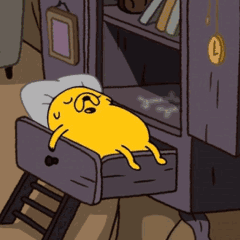

In [12]:
TestImage('jake_64_colors(240x240).bin','jake_64_colors(240x240)-ColorTable.txt',(240,240),6)

CodeTable len:  686


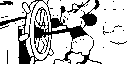

In [13]:
TestImage('steam_boat_monocrome(128x64).bin','steam_boat_monocrome(128x64)-ColorTable.txt',(128,64),2)